# 3. Hannah Inversion Visualization

This notebook summarizes Hannah inversion outputs with coordinated 2D slices, 3D pseudo-geology views, and property-space crossplots.


## Block 1: Load Models and Define Slice Locations

Load density/susceptibility/geo-group volumes, parse the tensor mesh, and map requested z/y targets to nearest mesh indices.


In [9]:
import numpy as np
from pathlib import Path

# -------------------------
# Block 1: Load Models and Define Slice Locations
# -------------------------
ROOT = Path.cwd()
proj_dir = ROOT / "Hannah_Inversion_GPT"

unit_path = proj_dir / "geology_models" / "geo_id_3d.npy"
susc_path = proj_dir / "inversion_result" / "joint_susceptibility_core.npy"
dens_path = proj_dir / "inversion_result" / "joint_density_core.npy"
mesh_path = proj_dir / "mesh" / "mesh_core.msh"

# Option A: select slices by physical coordinates (recommended)
depth_targets_m = [-1782.0, -3422.0, -5821.0]  # three depth/elevation targets (m)
y_targets_m = [4303250.0]  # one Y-section target (m)

# Option B: select slices by explicit indices (optional)
depth_indices = None
y_indices = None  

# -------------------------
# Helpers
# -------------------------
def _parse_mesh_axis_line(line: str, n: int) -> np.ndarray:
    vals = np.array([float(v) for v in line.strip().split()], dtype=float)
    if vals.size != n:
        raise ValueError(f"Expected {n} values, got {vals.size}: {line[:80]}...")
    return vals

def read_ubc_tensor_mesh(mesh_file: Path):
    lines = [ln for ln in mesh_file.read_text(encoding="utf-8").splitlines() if ln.strip()]
    if len(lines) < 5:
        raise ValueError(f"Invalid mesh file: {mesh_file}")

    nx, ny, nz = [int(v) for v in lines[0].split()]
    x0, y0, z0 = [float(v) for v in lines[1].split()]
    hx = _parse_mesh_axis_line(lines[2], nx)
    hy = _parse_mesh_axis_line(lines[3], ny)
    hz = _parse_mesh_axis_line(lines[4], nz)

    x_edges = x0 + np.r_[0.0, np.cumsum(hx)]
    y_edges = y0 + np.r_[0.0, np.cumsum(hy)]

    # UBC mesh stores z0 at top. Reverse to ascending bottom->top
    # so indexing matches saved core npy arrays (k=0 is deepest).
    z_edges_top_to_bottom = z0 - np.r_[0.0, np.cumsum(hz)]
    z_edges = z_edges_top_to_bottom[::-1]

    x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
    y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])
    z_centers = 0.5 * (z_edges[:-1] + z_edges[1:])

    return (nx, ny, nz), x_edges, y_edges, z_edges, x_centers, y_centers, z_centers

def pick_indices(axis_values: np.ndarray, target_values, explicit_indices, axis_name: str):
    n = axis_values.size
    if explicit_indices is not None:
        idx = [int(np.clip(i, 0, n - 1)) for i in explicit_indices]
        if len(idx) == 0:
            raise ValueError(f"{axis_name} explicit indices must not be empty")
        return idx

    if target_values is None or len(target_values) == 0:
        raise ValueError(f"{axis_name} target values must not be empty")

    idx = [int(np.argmin(np.abs(axis_values - float(t)))) for t in target_values]
    return idx

# -------------------------
# Read arrays + mesh coordinates
# -------------------------
unit_id = np.load(unit_path)
susc = np.load(susc_path)
dens = np.load(dens_path)

if dens.shape != susc.shape or dens.shape != unit_id.shape:
    raise ValueError(f"Shape mismatch: dens={dens.shape}, susc={susc.shape}, unit={unit_id.shape}")

(nx, ny, nz), x_edges, y_edges, z_edges, x_centers, y_centers, z_centers = read_ubc_tensor_mesh(mesh_path)
if (nx, ny, nz) != dens.shape:
    raise ValueError(f"Mesh shape {(nx, ny, nz)} != model shape {dens.shape}")

k_indices = pick_indices(z_centers, depth_targets_m, depth_indices, "depth")
j_indices = pick_indices(y_centers, y_targets_m, y_indices, "y")

print("Data shape (nx, ny, nz):", dens.shape)
print("X range:", float(x_edges[0]), "to", float(x_edges[-1]))
print("Y range:", float(y_edges[0]), "to", float(y_edges[-1]))
print("Z range:", float(z_edges[0]), "to", float(z_edges[-1]))
print()
print("Selected depth slices (k, z[m]):")
for k in k_indices:
    print(f"  k={k:02d}, z={z_centers[k]:.1f}")
print("Selected Y sections (j, y[m]):")
for j in j_indices:
    print(f"  j={j:02d}, y={y_centers[j]:.1f}")


Data shape (nx, ny, nz): (50, 60, 40)
X range: 510000.0 to 535000.0
Y range: 4290000.0 to 4320000.0
Z range: -9862.987680999999 to 1599.58953

Selected depth slices (k, z[m]):
  k=12, z=-1782.3
  k=08, z=-3421.5
  k=04, z=-5821.4
Selected Y sections (j, y[m]):
  j=26, y=4303250.0


## Block 2: Multi-Panel Slice Figure

Plot three depth slices plus one Y-section in a 3-column layout (Density, Susceptibility, Geo Group) with shared bottom colorbars.


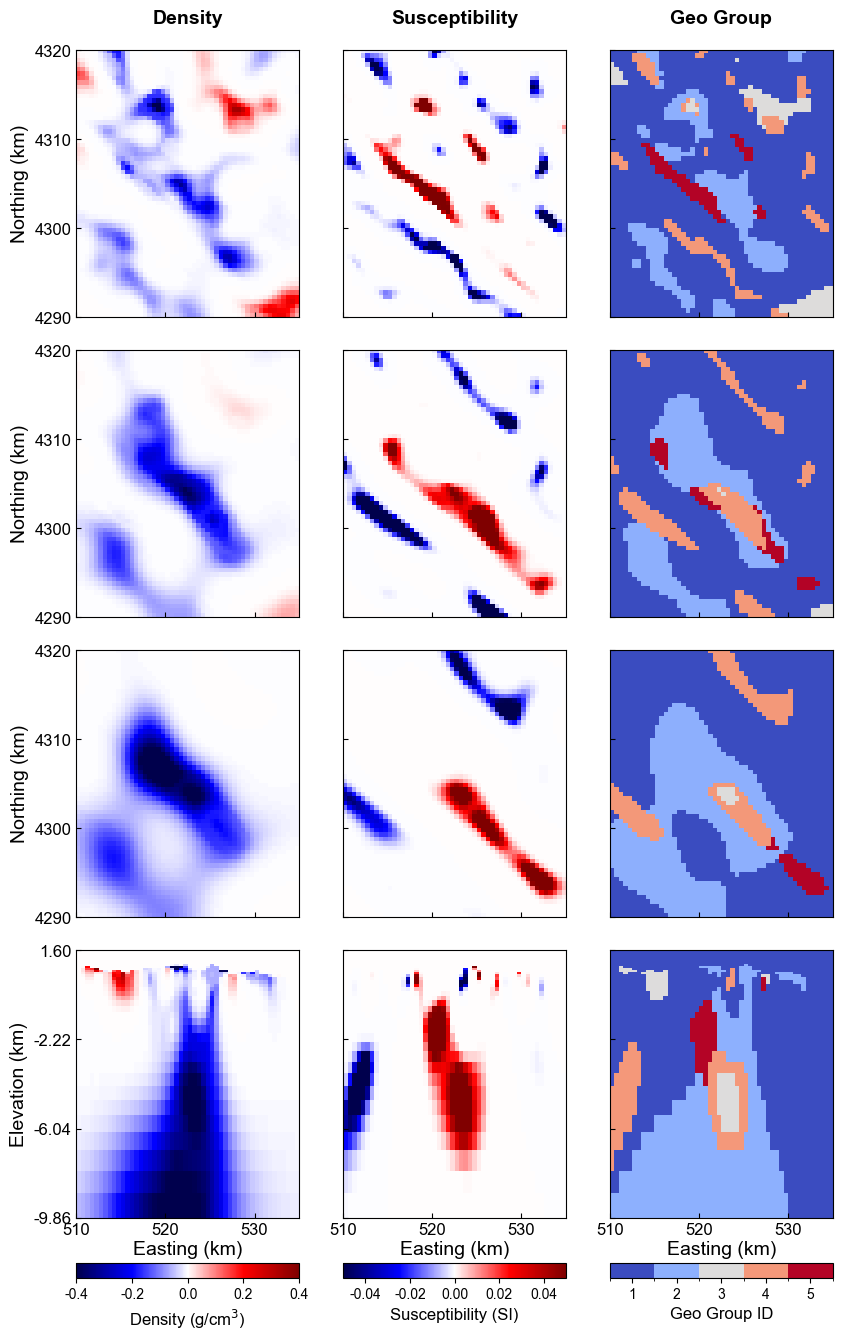

Saved: Figure\Figure4_Hannah_inversion_Geogroup_slices.png


In [10]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap

# -------------------------
# Block 2: Multi-Panel Slice Figure Configuration
# Rows: selected z-slices and y-sections
# Columns: Density / Susceptibility / Geo Group
# -------------------------
dens_vmin, dens_vmax = -0.4, 0.4
susc_vmin, susc_vmax = -0.05, 0.05

# Global font settings
mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["font.sans-serif"] = ["Arial"]
mpl.rcParams["axes.unicode_minus"] = False

cmap_cont = plt.get_cmap("seismic")

geo_values = np.unique(unit_id.astype(int))
geo_values = np.sort(geo_values)
if geo_values.size == 1:
    geo_bounds = np.array([geo_values[0] - 0.5, geo_values[0] + 0.5], dtype=float)
else:
    geo_bounds = np.empty(geo_values.size + 1, dtype=float)
    geo_bounds[1:-1] = 0.5 * (geo_values[:-1] + geo_values[1:])
    geo_bounds[0] = geo_values[0] - 0.5
    geo_bounds[-1] = geo_values[-1] + 0.5

geo_base = plt.get_cmap("coolwarm")
geo_colors = geo_base(np.linspace(0.0, 1.0, geo_values.size))
cmap_geo = ListedColormap(geo_colors, name="coolwarm_discrete_geo")
norm_geo = BoundaryNorm(geo_bounds, cmap_geo.N, clip=True)

rows = [
    *(("xy", k, float(z_centers[k])) for k in k_indices),
    *(("xz", j, float(y_centers[j])) for j in j_indices),
]
n_rows = len(rows)
if n_rows == 0:
    raise ValueError("No slice/section rows found.")

x_edges_km = x_edges / 1000.0
y_edges_km = y_edges / 1000.0
z_edges_km = z_edges / 1000.0

fig = plt.figure(figsize=(10, 15), constrained_layout=False)
gs = fig.add_gridspec(
    nrows=n_rows + 1,
    ncols=3,
    height_ratios=[1.0] * n_rows + [0.11],
    left=0.16,
    right=0.95,
    top=0.94,
    bottom=0.12,
    wspace=0.04,
    hspace=0.15,
)

axes = np.empty((n_rows, 3), dtype=object)
for r in range(n_rows):
    for c in range(3):
        axes[r, c] = fig.add_subplot(gs[r, c])

# Use XY domain ratio to keep the last-row box size consistent.
xy_box_aspect = (y_edges[-1] - y_edges[0]) / (x_edges[-1] - x_edges[0])

m_d_ref = None
m_s_ref = None
m_g_ref = None

for r, (mode, idx, _) in enumerate(rows):
    ax_d, ax_s, ax_g = axes[r, 0], axes[r, 1], axes[r, 2]

    if mode == "xy":
        k = idx
        dens_slice = dens[:, :, k].T
        susc_slice = susc[:, :, k].T
        geo_slice = unit_id[:, :, k].T

        m_d = ax_d.imshow(
            dens_slice,
            origin="lower",
            extent=[x_edges_km[0], x_edges_km[-1], y_edges_km[0], y_edges_km[-1]],
            cmap=cmap_cont,
            vmin=dens_vmin,
            vmax=dens_vmax,
            interpolation="nearest",
        )
        m_s = ax_s.imshow(
            susc_slice,
            origin="lower",
            extent=[x_edges_km[0], x_edges_km[-1], y_edges_km[0], y_edges_km[-1]],
            cmap=cmap_cont,
            vmin=susc_vmin,
            vmax=susc_vmax,
            interpolation="nearest",
        )
        m_g = ax_g.imshow(
            geo_slice,
            origin="lower",
            extent=[x_edges_km[0], x_edges_km[-1], y_edges_km[0], y_edges_km[-1]],
            cmap=cmap_geo,
            norm=norm_geo,
            interpolation="nearest",
        )

        for ax in (ax_d, ax_s, ax_g):
            ax.set_ylim(y_edges_km[0], y_edges_km[-1])

        ylab = "Northing (km)"

    else:
        j = idx
        dens_sec = dens[:, j, :].T
        susc_sec = susc[:, j, :].T
        geo_sec = unit_id[:, j, :].T

        m_d = ax_d.pcolormesh(
            x_edges_km,
            z_edges_km,
            dens_sec,
            shading="auto",
            cmap=cmap_cont,
            vmin=dens_vmin,
            vmax=dens_vmax,
        )
        m_s = ax_s.pcolormesh(
            x_edges_km,
            z_edges_km,
            susc_sec,
            shading="auto",
            cmap=cmap_cont,
            vmin=susc_vmin,
            vmax=susc_vmax,
        )
        m_g = ax_g.pcolormesh(
            x_edges_km,
            z_edges_km,
            geo_sec,
            shading="auto",
            cmap=cmap_geo,
            norm=norm_geo,
        )

        for ax in (ax_d, ax_s, ax_g):
            ax.set_ylim(z_edges_km[0], z_edges_km[-1])

        ylab = "Elevation (km)"

    for c, ax in enumerate((ax_d, ax_s, ax_g)):
        ax.set_xlim(x_edges_km[0], x_edges_km[-1])

        # Tick positions
        ax.set_xticks([510, 520, 530])
        y0, y1 = ax.get_ylim()
        ax.set_yticks(np.linspace(y0, y1, 4))
        ax.tick_params(direction="in", labelsize=12)

        # Keep the last row panel width consistent with the first three rows
        if r == n_rows - 1:
            ax.set_aspect("auto")
            ax.set_box_aspect(xy_box_aspect)

        # Aspect rules
        if r == n_rows - 1:
            ax.set_xlabel("Easting (km)", labelpad=2, fontsize=14)
        else:
            ax.set_xlabel("")
            ax.tick_params(labelbottom=False)

        if c == 0:
            ax.set_ylabel(ylab, fontsize=14)
        else:
            ax.set_ylabel("")
            ax.tick_params(labelleft=False)


    if m_d_ref is None:
        m_d_ref = m_d
    if m_s_ref is None:
        m_s_ref = m_s
    if m_g_ref is None:
        m_g_ref = m_g

# Column headers at top
col_titles = ["Density", "Susceptibility", "Geo Group"]
for c, title in enumerate(col_titles):
    pos = axes[0, c].get_position()
    xc = 0.5 * (pos.x0 + pos.x1)
    fig.text(xc, 0.955, title, ha="center", va="bottom", fontsize=14, fontweight="bold")


# Bottom colorbars (aligned to actual panel width, without occupying a grid column)
fig.canvas.draw()
cb_h = 0.01
cb_gap = 0.03

pos_d = axes[n_rows - 1, 0].get_position()
pos_s = axes[n_rows - 1, 1].get_position()
pos_g = axes[n_rows - 1, 2].get_position()

cax_d = fig.add_axes([pos_d.x0, pos_d.y0 - cb_gap - cb_h, pos_d.width, cb_h])
cax_s = fig.add_axes([pos_s.x0, pos_s.y0 - cb_gap - cb_h, pos_s.width, cb_h])
cax_g = fig.add_axes([pos_g.x0, pos_g.y0 - cb_gap - cb_h, pos_g.width, cb_h])

cbar_d = fig.colorbar(m_d_ref, cax=cax_d, orientation="horizontal")
cbar_d.set_label(r"Density (g/cm$^3$)", fontsize=12)

cbar_s = fig.colorbar(m_s_ref, cax=cax_s, orientation="horizontal")
cbar_s.set_label("Susceptibility (SI)", fontsize=12)

cbar_g = fig.colorbar(m_g_ref, cax=cax_g, orientation="horizontal")
cbar_g.set_label("Geo Group ID", fontsize=12)
if geo_values.size <= 12:
    cbar_g.set_ticks(geo_values)
else:
    step = int(np.ceil(geo_values.size / 12))
    cbar_g.set_ticks(geo_values[::step])

out_dir = ROOT / "Figure"
out_dir.mkdir(parents=True, exist_ok=True)
out_png = out_dir / "Figure4_Hannah_inversion_Geogroup_slices.png"
fig.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()
print(f"Saved: {out_png.relative_to(ROOT)}")


## Block 3: 3D Pseudo-Geology Panels

Render a no-background 3D view and single-body Geo ID panels (1-5), then assemble a 2x3 summary with one global colorbar.


Saved 3D overall (no background): Figure\Hannah_geo3d_panels\geo_model_without_background.jpg
Saved 3D single geo_id=1: Figure\Hannah_geo3d_panels\geo_id_1.jpg
Saved 3D single geo_id=2: Figure\Hannah_geo3d_panels\geo_id_2.jpg
Saved 3D single geo_id=3: Figure\Hannah_geo3d_panels\geo_id_3.jpg
Saved 3D single geo_id=4: Figure\Hannah_geo3d_panels\geo_id_4.jpg
Saved 3D single geo_id=5: Figure\Hannah_geo3d_panels\geo_id_5.jpg


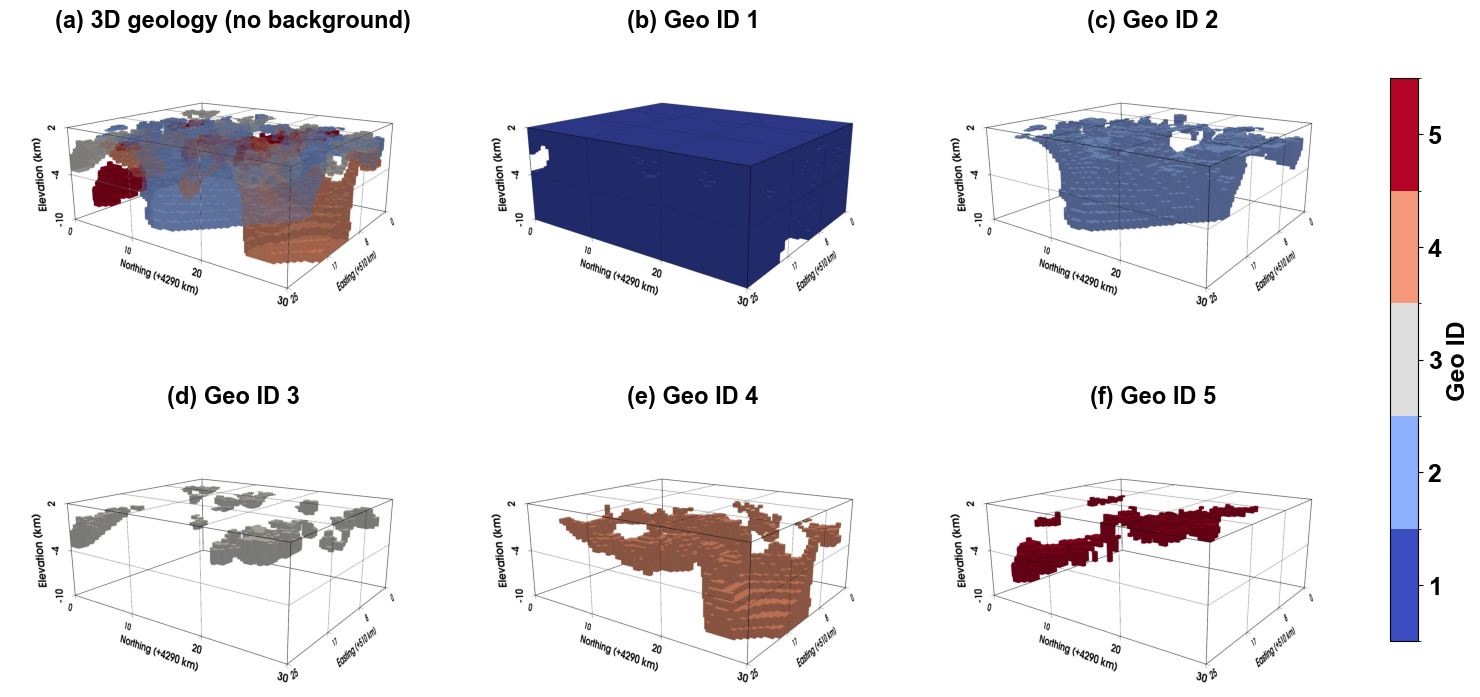

Saved 2x3 summary: Figure\Figure5_Hannah_geo_3d.png


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import ListedColormap, BoundaryNorm
from pathlib import Path

import pyvista as pv

# Typography controls
mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["font.sans-serif"] = ["Arial"]
TITLE_FONTSIZE = 17

# -------------------------
# Block 3: 3D Pseudo-Geology Panels (2x3)
# (a) no-background overall model
# (b-f) single-body views for Geo ID 1-5
# -------------------------
ROOT = globals().get("ROOT", Path.cwd())
proj_dir = ROOT / "Hannah_Inversion_GPT"
mesh_path = proj_dir / "mesh" / "mesh_core.msh"
geo_id_path = proj_dir / "geology_models" / "geo_id_3d.npy"
if not geo_id_path.exists():
    geo_id_path = proj_dir / "geology_models" / "unit_id_3d.npy"

if not geo_id_path.exists():
    raise FileNotFoundError(f"Cannot find geo labels: {geo_id_path}")

# Reuse mesh edges if available; otherwise parse mesh here.
if "x_edges" not in globals() or "y_edges" not in globals() or "z_edges" not in globals():
    def _parse_mesh_axis_line(line: str, n: int) -> np.ndarray:
        vals = np.array([float(v) for v in line.strip().split()], dtype=float)
        if vals.size != n:
            raise ValueError(f"Expected {n} values, got {vals.size}")
        return vals

    def read_ubc_tensor_mesh(mesh_file: Path):
        lines = [ln for ln in mesh_file.read_text(encoding="utf-8").splitlines() if ln.strip()]
        nx, ny, nz = [int(v) for v in lines[0].split()]
        x0, y0, z0 = [float(v) for v in lines[1].split()]
        hx = _parse_mesh_axis_line(lines[2], nx)
        hy = _parse_mesh_axis_line(lines[3], ny)
        hz = _parse_mesh_axis_line(lines[4], nz)

        x_edges_local = x0 + np.r_[0.0, np.cumsum(hx)]
        y_edges_local = y0 + np.r_[0.0, np.cumsum(hy)]
        z_edges_top_to_bottom = z0 - np.r_[0.0, np.cumsum(hz)]
        z_edges_local = z_edges_top_to_bottom[::-1]
        return (nx, ny, nz), x_edges_local, y_edges_local, z_edges_local

    (nx, ny, nz), x_edges, y_edges, z_edges = read_ubc_tensor_mesh(mesh_path)
else:
    nx = len(x_edges) - 1
    ny = len(y_edges) - 1
    nz = len(z_edges) - 1

geo_id_3d = np.load(geo_id_path).astype(np.int16)
if geo_id_3d.shape != (nx, ny, nz):
    raise ValueError(f"geo_id shape {geo_id_3d.shape} != mesh shape {(nx, ny, nz)}")

x_nodes = np.asarray(x_edges, dtype=float)
y_nodes = np.asarray(y_edges, dtype=float)
z_nodes = np.asarray(z_edges, dtype=float)

grid = pv.RectilinearGrid(x_nodes, y_nodes, z_nodes)
geo_flat_plot = geo_id_3d.ravel(order="F").astype(np.int16)
grid.cell_data["geo_id"] = geo_flat_plot

all_geo_ids = np.unique(geo_flat_plot)
all_geo_ids = all_geo_ids[all_geo_ids > 0]
if all_geo_ids.size == 0:
    raise ValueError("No positive geo_id found for 3D plotting.")

min_id = int(np.min(all_geo_ids))
max_id = int(np.max(all_geo_ids))
n_colors = max_id - min_id + 1
base = mpl.colormaps.get_cmap("coolwarm").resampled(n_colors)
colors = [base(i) for i in range(n_colors)]
cmap_geo = ListedColormap(colors)
clim = (min_id, max_id)

def setup_bounds(plotter, grid_obj, font_size=30):
    xmin, xmax, ymin, ymax, zmin, zmax = grid_obj.bounds

    # Use relative kilometer axes from local origin (0 at xmin/ymin).
    xmin_km, xmax_km = xmin / 1000.0, xmax / 1000.0
    ymin_km, ymax_km = ymin / 1000.0, ymax / 1000.0
    zmin_km, zmax_km = zmin / 1000.0, zmax / 1000.0
    dx_km = xmax_km - xmin_km
    dy_km = ymax_km - ymin_km

    actor = plotter.show_bounds(
        grid="front",
        location="outer",
        all_edges=False,
        xtitle=f"Easting (+{xmin_km:.0f} km)",
        ytitle=f"Northing (+{ymin_km:.0f} km)",
        ztitle="Elevation (km)",
        axes_ranges=[0.0, dx_km, 0.0, dy_km, zmin_km, zmax_km],
        fmt="%.0f",
        font_size=font_size,
        n_xlabels=4,
        n_ylabels=4,
        n_zlabels=3,
    )

    actor.SetTickLocationToOutside()
    # Force label formats explicitly: X/Y integer, Z one decimal.
    if hasattr(actor, "SetLabelFormat"):
        actor.SetLabelFormat("%.1f")
    if hasattr(actor, "SetXLabelFormat"):
        actor.SetXLabelFormat("%.0f")
    if hasattr(actor, "SetYLabelFormat"):
        actor.SetYLabelFormat("%.0f")
    if hasattr(actor, "SetZLabelFormat"):
        actor.SetZLabelFormat("%.1f")
    actor.label_offset = 30


def setup_camera(plotter, grid_obj, zoom=1.0):
    xmin, xmax, ymin, ymax, zmin, zmax = grid_obj.bounds
    center = ((xmin + xmax) / 2, (ymin + ymax) / 2, (zmin + zmax) / 2)
    dx, dy, dz = xmax - xmin, ymax - ymin, zmax - zmin
    plotter.camera_position = [
        (center[0] + 2 * dx, center[1] + 1.2*dy, center[2] + 1.5 * dz),
        center,
        (0, 0, 1),
    ]
    plotter.camera.zoom(zoom)

panel_dir = ROOT / "Figure" / "Hannah_geo3d_panels"
panel_dir.mkdir(parents=True, exist_ok=True)

# Panel 1: overall without background (remove geo_id 0 and 1)
mask_nobg = (geo_flat_plot != 0) & (geo_flat_plot != 1)
if not np.any(mask_nobg):
    mask_nobg = geo_flat_plot != 0

overall_path = panel_dir / "geo_model_without_background.jpg"
grid_nobg = grid.extract_cells(mask_nobg)
p = pv.Plotter(off_screen=True, window_size=(1600, 1000))
p.set_background("white")
p.add_mesh(
    grid_nobg,
    scalars="geo_id",
    cmap=cmap_geo,
    show_edges=False,
    show_scalar_bar=False,
    opacity=0.95,
    clim=clim,
)
p.add_mesh(grid.outline(), color="black", line_width=2)
setup_bounds(p, grid)
setup_camera(p, grid, zoom=1)
p.screenshot(str(overall_path))
p.close()
print(f"Saved 3D overall (no background): {overall_path.relative_to(ROOT)}")

single_paths = []
for gid in [1, 2, 3, 4, 5]:
    out_single = panel_dir / f"geo_id_{gid}.jpg"
    mask_show = geo_flat_plot == gid
    if np.any(mask_show):
        grid_show = grid.extract_cells(mask_show)
        p = pv.Plotter(off_screen=True, window_size=(1600, 1000))
        p.set_background("white")
        p.add_mesh(
            grid_show,
            scalars="geo_id",
            cmap=cmap_geo,
            show_edges=False,
            show_scalar_bar=False,
            opacity=1.0,
            clim=clim,
        )
        p.add_mesh(grid.outline(), color="black", line_width=2)
        setup_bounds(p, grid)
        setup_camera(p, grid, zoom=1)
        p.screenshot(str(out_single))
        p.close()
        print(f"Saved 3D single geo_id={gid}: {out_single.relative_to(ROOT)}")
    else:
        print(f"geo_id={gid} not present; panel will be blank text.")
    single_paths.append((gid, out_single if out_single.exists() else None))

# Combine to 2x3 layout
fig, axes = plt.subplots(2, 3, figsize=(16, 8), constrained_layout=False)
axes = axes.ravel()
fig.subplots_adjust(left=0.02, right=0.90, top=0.96, bottom=0.03, wspace=0.03, hspace=0.02)

panel_items = [("(a) 3D geology (no background)", overall_path)]
panel_items += [(f"({chr(98 + i)}) Geo ID {gid}", pth) for i, (gid, pth) in enumerate(single_paths)]

for ax, (title, img_path) in zip(axes, panel_items):
    if img_path is not None and Path(img_path).exists():
        img = plt.imread(img_path)
        ax.imshow(img)
    else:
        ax.text(0.5, 0.5, "Not found", ha="center", va="center", fontsize=12)
    ax.set_title(title, pad=2, fontsize=TITLE_FONTSIZE, fontweight="bold", fontname="Arial")
    ax.axis("off")

# One global colorbar for the whole 2x3 figure
bounds = np.arange(min_id - 0.5, max_id + 1.5, 1.0)
norm = BoundaryNorm(bounds, ncolors=cmap_geo.N, clip=True)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap_geo)
sm.set_array([])
cbar = fig.colorbar(
    sm,
    ax=axes.tolist(),
    fraction=0.020,
    pad=0.01,
)
cbar.set_label("Geo ID", fontsize=18, fontweight="bold", family="Arial")
cbar.set_ticks(np.arange(min_id, max_id + 1, 1))
cbar.ax.tick_params(labelsize=18)
for t in cbar.ax.get_yticklabels():
    t.set_fontname("Arial")
    t.set_fontweight("bold")

out_dir = ROOT / "Figure"
out_dir.mkdir(parents=True, exist_ok=True)
out_png = out_dir / "Figure5_Hannah_geo_3d.png"
fig.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()
print(f"Saved 2x3 summary: {out_png.relative_to(ROOT)}")

## Block 4: Density-Susceptibility Crossplot by Unit ID

Create a voxel-level density-versus-susceptibility crossplot colored by unit ID to inspect class separation.


Using unit labels from: Hannah_Inversion_GPT\geology_models\unit_id_3d.npy
Loaded unit definitions: Hannah\Hannah_unit_defs.csv


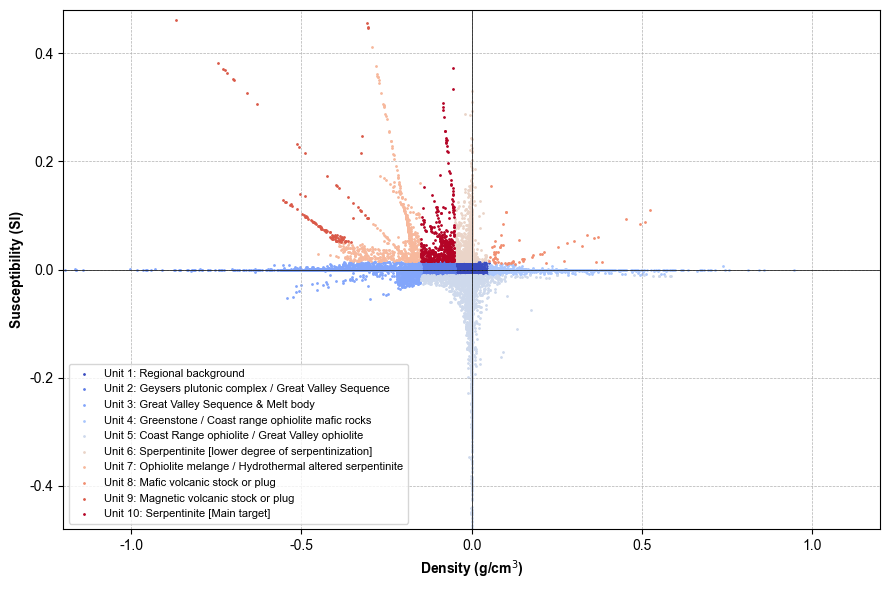

Saved: Figure\FigureS1_Hannah_density_susceptibility_croosplot.png


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path

mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["font.sans-serif"] = ["Arial"]
mpl.rcParams["axes.unicode_minus"] = False

# -------------------------
# Block 4: Property-Space Crossplot (Density vs Susceptibility by Unit ID)
# -------------------------
ROOT = globals().get("ROOT", Path.cwd())
proj_dir = ROOT / "Hannah_Inversion_GPT"

unit_id_file = proj_dir / "geology_models" / "unit_id_3d.npy"
if not unit_id_file.exists():
    unit_id_file = proj_dir / "geology_models" / "geo_id_3d.npy"

if "dens" not in globals() or "susc" not in globals():
    susc = np.load(proj_dir / "inversion_result" / "joint_susceptibility_core.npy")
    dens = np.load(proj_dir / "inversion_result" / "joint_density_core.npy")

# Always reload unit labels from file to match geo_modeling_workflow.py behavior.
unit_id = np.load(unit_id_file)
print(f"Using unit labels from: {unit_id_file.relative_to(ROOT)}")

if dens.shape != susc.shape or dens.shape != unit_id.shape:
    raise ValueError(f"Shape mismatch: dens={dens.shape}, susc={susc.shape}, unit={unit_id.shape}")

dens_flat = dens.ravel()
susc_flat = susc.ravel()
unit_flat = unit_id.astype(int).ravel()

# Load unit names for legend labels from a fixed path
unit_defs = {}
unit_defs_path = ROOT / "Hannah" / "Hannah_unit_defs.csv"
if unit_defs_path.exists():
    df_unit = pd.read_csv(unit_defs_path)
    if {"unit_id", "name"}.issubset(df_unit.columns):
        for r in df_unit.itertuples(index=False):
            unit_defs[int(r.unit_id)] = {"name": str(r.name)}
    print(f"Loaded unit definitions: {unit_defs_path.relative_to(ROOT)}")

plt.figure(figsize=(9, 6))
unique_ids = np.unique(unit_flat)
has_unclassified = 0 in unique_ids
unique_ids = unique_ids[unique_ids != 0]
unique_ids = np.sort(unique_ids)

n_units = len(unique_ids)
cmap = mpl.colormaps.get_cmap("coolwarm").resampled(max(n_units, 1))

for i, uid in enumerate(unique_ids):
    mask = unit_flat == uid
    if not np.any(mask):
        continue
    label = f"Unit {uid}: {unit_defs.get(uid, {}).get('name', '')}"
    color = cmap(i)
    plt.scatter(
        dens_flat[mask],
        susc_flat[mask],
        s=1,
        alpha=1,
        label=label,
        color=color,
    )

if has_unclassified:
    mask0 = unit_flat == 0
    if np.any(mask0):
        plt.scatter(
            dens_flat[mask0],
            susc_flat[mask0],
            s=1,
            alpha=1,
            color="lightgray",
            label="Unclassified (0)",
        )

plt.axhline(0.0, color="k", linewidth=0.5)
plt.axvline(0.0, color="k", linewidth=0.5)

# Fixed display range for consistent visual comparison across runs
dens_min, dens_max = -1, 1
susc_min, susc_max = -0.4, 0.4

dens_pad = (dens_max - dens_min) * 0.1 if dens_max != dens_min else 0.1
susc_pad = (susc_max - susc_min) * 0.1 if susc_max != susc_min else 0.01

plt.xlim(dens_min - dens_pad, dens_max + dens_pad)
plt.ylim(susc_min - susc_pad, susc_max + susc_pad)

plt.xlabel(r"Density (g/cm$^3$)", fontweight="bold")
plt.ylabel("Susceptibility (SI)", fontweight="bold")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.legend(loc="lower left", fontsize=8, frameon=True)
plt.tight_layout()

out_dir = ROOT / "Figure"
out_dir.mkdir(parents=True, exist_ok=True)
out_png = out_dir / "FigureS1_Hannah_density_susceptibility_croosplot.png"
plt.savefig(out_png, dpi=600)
plt.show()
print(f"Saved: {out_png.relative_to(ROOT)}")
